# Extrapolation in the Elf-Owl models 

I want to try to fit a power law into the areas of the wavelength that aren't covered by the native model. 

Currently, we're looking at the elf owl models, which end at 15um, and the F1550C filter which go from 14.9 to around 16um. So we're missing a lot, and the species model breaks down. 

So we're going to try out the power law, verify, and see what happens. 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from dwarfhunt import planets as helpers
from species.read.read_model import ReadModel
from species.read.read_filter import ReadFilter
import dwarfhunt


db = dwarfhunt.init()



/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


species



Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Retrieve the data
Only run this section if you don't have the model + filters downloaded.

Note: `wavel_range` is capped at `(.61, 14.9)` here, not `18.`. Elf Owl's grid stops at
14.9 um regardless of what's requested.

In [ ]:
db.add_model('sonora-elfowl-t', wavel_range=(.61, 14.9), wavel_sampling=1000.0)
db.add_model('sonora-elfowl-y', wavel_range=(.61, 14.9), wavel_sampling=1000.0)
db.add_filter('JWST/MIRI.F1065C')
db.add_filter('JWST/MIRI.F1140C')
db.add_filter('JWST/MIRI.F1550C')

Now we'll pull down the model, and get the wavelength / flux so I can start doing the power law

We're now directly going to the .hdf5 db to pull the spectrum we need, which saves time. the model.getData function loads the entire grid on the call, where as we're targeting specific grid points, we can just look them up. 

In [2]:
model = ReadModel('sonora-elfowl-t', wavel_range=(.61, 14.9))
model_y = ReadModel('sonora-elfowl-y', wavel_range=(.61, 14.9))

model_t_data = helpers.generate_planet_arrays(model, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=helpers.deny_list())
model_y_data = helpers.generate_planet_arrays(model_y, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=helpers.deny_list())

# Validation: fit the power law on 12-14um (the clean stretch before the grid's edge),
# then check its prediction against the *real* model flux on 14-14.9um. That's the one
# place we can compare against ground truth, since 14.9-16.6um (where F1550C actually
# needs the extrapolation) doesn't exist in the grid at all.
result_t = helpers.extrapolation_residuals('sonora-elfowl-t', model_t_data, fit_range=(12.0, 14.0), test_range=(14.0, 14.9))
result_y = helpers.extrapolation_residuals('sonora-elfowl-y', model_y_data, fit_range=(12.0, 14.0), test_range=(14.0, 14.9))

sonora-elfowl-t: dropping logg = [np.float64(3.0)] (no spectra)
sonora-elfowl-y: dropping logg = [np.float64(3.0)] (no spectra)


### Summary table, per model

Below generates a table for the residuals detected in the experiments. This should show us how good each model is doing based on the ranges of the residuals. 

In [3]:
import pandas as pd

rows = []
for result in (result_t, result_y):
    r = result["residual"] * 100  # percent
    rows.append({
        "model": result["tag"],
        "p16 residual (%)": np.nanpercentile(r, 16),
        "median residual (%)": np.nanmedian(r),
        "p84 residual (%)": np.nanpercentile(r, 84),
        "p84 |residual| (%)": np.nanpercentile(np.abs(r), 84),
    })

summary = pd.DataFrame(rows).set_index("model").round(1)
summary

,p16 residual (%),median residual (%),p84 residual (%),p84 |residual| (%)
model,,,,
sonora-elfowl-t,-15.4,-1.7,21.2,26.4
sonora-elfowl-y,-7.7,11.6,46.2,46.2


### Same residual, binned by Teff instead of wavelength

`generate_planet_arrays` samples teff from the grid's own axis values, so grouping by
the exact value recovers the grid's real temperature steps (12 per model) rather than
needing arbitrary bin edges. Same signed-percentile convention as the table above: the
median always sits between p16 and p84 by construction, and `p84 |residual|` is kept
as a separate "how bad does a typical bad channel get" column.

In [4]:
teff_table_t = pd.DataFrame(helpers.residual_by_teff(result_t)).set_index("teff").round(1)
teff_table_y = pd.DataFrame(helpers.residual_by_teff(result_y)).set_index("teff").round(1)

print("sonora-elfowl-t")
display(teff_table_t)
print("sonora-elfowl-y")
display(teff_table_y)

sonora-elfowl-t


,n_planets,p16 residual (%),median residual (%),p84 residual (%),p84 |residual| (%)
teff,,,,,
575.0,21,-14.9,1.3,36.8,36.8
600.0,13,-13.0,0.3,26.6,31.5
650.0,16,-13.5,-0.9,24.8,28.6
700.0,13,-14.2,-0.5,25.9,28.0
750.0,17,-19.5,-3.1,19.3,29.7
800.0,16,-13.8,0.4,24.6,26.3
850.0,20,-14.3,-0.6,22.4,26.6
900.0,22,-18.5,-4.3,17.7,26.0
950.0,9,-17.7,-3.5,16.2,23.5


sonora-elfowl-y


,n_planets,p16 residual (%),median residual (%),p84 residual (%),p84 |residual| (%)
teff,,,,,
275.0,9,17.2,41.4,83.7,83.7
300.0,15,7.3,25.7,64.7,64.7
325.0,24,2.6,21.2,56.1,56.1
350.0,19,1.1,18.0,45.4,45.4
375.0,12,-2.7,11.6,40.7,40.7
400.0,17,-11.7,9.2,44.1,44.1
425.0,14,-5.9,10.4,34.3,35.4
450.0,15,-11.5,6.2,37.9,37.9
475.0,19,-13.2,3.8,34.5,36.2


### Does the fast path agree with `species`?

`get_planet_spectra` reads the HDF5 grid directly instead of going through
`species.ReadModel.get_data`, on the reasoning that every sampled planet sits exactly on a
grid node so there's no interpolation to verify. `get_planet_spectra_via_species` is the
same interface implemented the slow way, through `get_data` itself, so the two can be
compared directly on the actual sampled planets rather than a single hand-picked one.
It costs ~18s per 200 planets (species reads the whole ~818 MB flux dataset per planet),
so this is worth running once, not on every pass.

In [5]:
for tag, planet_arrays in [('sonora-elfowl-t', model_t_data), ('sonora-elfowl-y', model_y_data)]:
    wl_fast, flux_fast = helpers.get_planet_spectra(tag, planet_arrays, wavel_range=(12.0, 14.9))
    wl_species, flux_species = helpers.get_planet_spectra_via_species(tag, planet_arrays, wavel_range=(12.0, 14.9))

    wl_match = np.array_equal(wl_fast, wl_species)
    flux_match = np.array_equal(flux_fast, flux_species)
    max_abs_diff = np.max(np.abs(flux_fast - flux_species))
    max_rel_diff = np.max(np.abs((flux_fast - flux_species) / flux_species))

    print(f"{tag}: wavelengths identical={wl_match}, flux bit-identical={flux_match}, "
          f"max abs diff={max_abs_diff:.3e}, max rel diff={max_rel_diff:.3e}")

sonora-elfowl-t: wavelengths identical=True, flux bit-identical=True, max abs diff=0.000e+00, max rel diff=0.000e+00


sonora-elfowl-y: wavelengths identical=True, flux bit-identical=True, max abs diff=0.000e+00, max rel diff=0.000e+00


(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'sonora-elfowl-t: power-law extrapolation residual (fit 12-14um, test 14-14.9um)'}, xlabel='Wavelength (µm)', ylabel='Residual (%)  [(predicted − actual) / actual]'>)

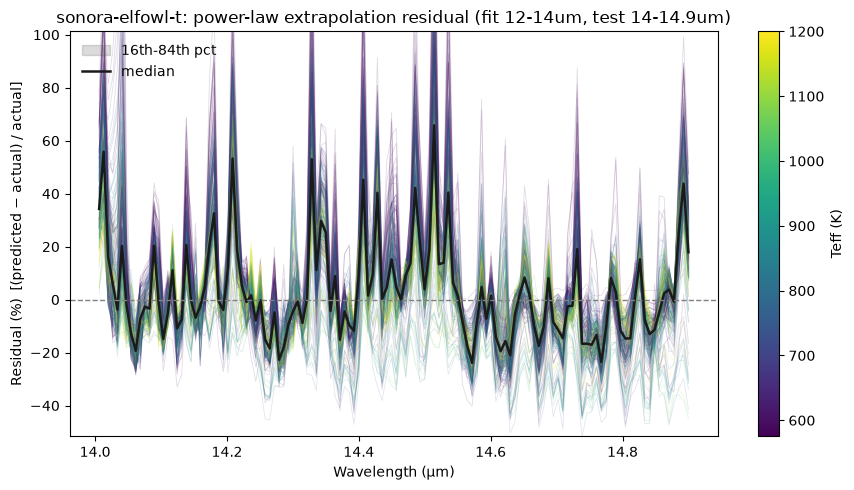

In [6]:
helpers.plot_extrapolation_residuals(result_t, title="sonora-elfowl-t: power-law extrapolation residual (fit 12-14um, test 14-14.9um)")

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'sonora-elfowl-y: power-law extrapolation residual (fit 12-14um, test 14-14.9um)'}, xlabel='Wavelength (µm)', ylabel='Residual (%)  [(predicted − actual) / actual]'>)

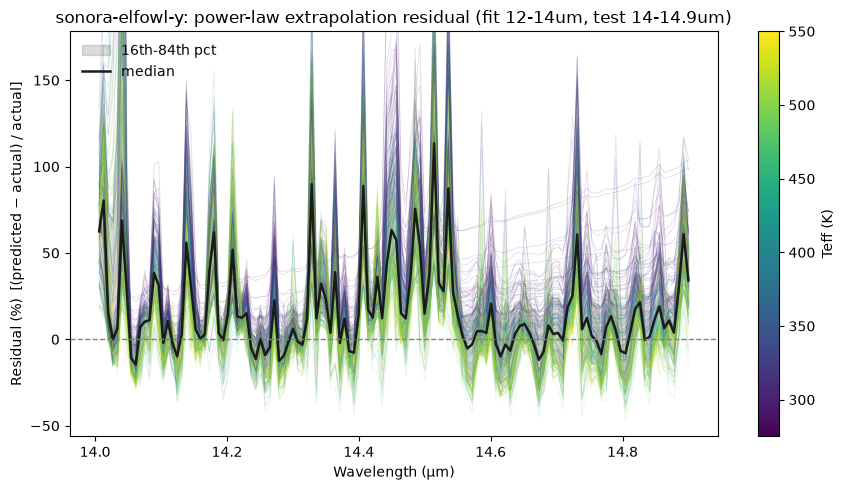

In [7]:
helpers.plot_extrapolation_residuals(result_y, title="sonora-elfowl-y: power-law extrapolation residual (fit 12-14um, test 14-14.9um)")

## Reading the residual

Each thin line is one sampled planet's `(predicted - actual) / actual` across 14-14.9um,
colored by Teff; the dark line and band are the median and 16th-84th percentile across all
200 planets.

What to look for: the power law is fit to the smooth continuum on 12-14um, so it should
track the continuum well on 14-14.9um too (median close to 0) but miss the molecular
absorption features baked into the real spectrum there (visible as the wide swings away
from 0 at specific wavelengths, shared across most planets since the same species -
methane, ammonia, etc. - absorb at the same wavelengths regardless of Teff). If that's what
these plots show, the power law is a reasonable stand-in for the *continuum* level past
14.9um but should not be trusted at wavelengths coinciding with real spectral features.

If the T and Y grids disagree noticeably (one run here showed Y roughly double T's
residual spread), that's worth a closer look before leaning on both equally.